<a href="https://colab.research.google.com/github/dhag/colab_demo/blob/main/HaGRID_CNN_feature_map_kyozai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNNの中間層応答を観察する教材 — HaGRID 手ジェスチャー編

**狙い:** 学習済みの畳み込みニューラルネット（CNN）に画像を通したとき、
各 **畳み込み層（Conv1, Conv2, Conv3 …）がどんな応答（feature map）を返すか** を
**画像としてそのまま観察** する。分類精度の評価が目的ではない。

---

### ⚠️ 重要な注意（最初に読む）

- ここで可視化する **feature map は、CNN が入力に対して返した「直接の応答」** である。
- これは **「分類にどこが寄与したか」を示すものではない**。
  feature map が明るい場所＝「その層のフィルタが強く反応した場所」であって、
  「ネットワークがそこを根拠に分類した場所」ではない。
- したがって本教材では **Grad-CAM などの分類寄与（attribution）可視化は一切使わない**。
  寄与の話と応答の話を混同しないことが、この教材の最大のポイント。

### この教材の流れ
1. HaGRID（手ジェスチャー画像データセット）の軽量サブセットと **bounding box アノテーション** を読み込む
2. bounding box で **手領域を切り出す**
3. 切り出した手画像で **ジェスチャー分類 CNN を学習** する（精度は主目的ではない）
4. 学習済み CNN に **3 種類の入力**（手だけ／全体画像／手を隠した全体画像）を通す
5. forward hook で **Conv1 / Conv2 / Conv3 の中間出力** を取り出す
6. 各 Conv 層の feature map を **チャンネルごとに正規化してタイル画像** にする
7. 各 Conv 層出力に **チャンネル方向 PCA** をかけ、**第1〜第4主成分を画像** にする
8. 全体画像には **手の bounding box を重ねて表示** する
9. **入力画像・予測ラベル・予測確率・生 feature map・PCA 画像** を並べて表示・保存する


## ステップ0：環境準備

Google Colab 想定。`torch` / `torchvision` / `scikit-learn` / `matplotlib` は Colab に同梱。
追加で `huggingface_hub`（データ取得）だけ入れる。**ランタイムは GPU 推奨**（CPU でも動くが学習が遅い）。

In [ ]:
# 追加インストール（HuggingFace からのデータ取得用）
!pip -q install huggingface_hub

import os, json, glob, random, math, time
from pathlib import Path
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.decomposition import PCA

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", DEVICE, "| torch", torch.__version__)

OUT_DIR = Path("/content/outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# 日本語フォント（matplotlib の凡例等に日本語を出したい場合。無ければ英語のまま）
try:
    !pip -q install japanize-matplotlib
    import japanize_matplotlib  # noqa
    print("japanize-matplotlib 有効")
except Exception as e:
    print("日本語フォントなしで続行:", e)


device = cuda | torch 2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 61.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
japanize-matplotlib 有効


### 設定（ここを変えると挙動が変わる）

- `SELECTED_CLASSES`：学習に使うジェスチャー（少なくすると軽い・速い）
- `MAX_PER_CLASS`：1クラスあたり使う最大画像数
- `IMG_SIZE`：CNN の入力サイズ（手の切り出し画像はここに合わせてリサイズ）
- `EPOCHS`：学習エポック数（feature map 観察が目的なので少なくてよい）

In [ ]:
# ---------------- 設定 ----------------
REPO_ID = "cj-mills/hagrid-sample-30k-384p"   # HuggingFace の Colab 向け軽量サブセット(31,833枚, 384p)

# HaGRID の 18 ジェスチャー: call dislike fist four like mute ok one palm
# peace peace_inverted rock stop stop_inverted three three2 two_up two_up_inverted
SELECTED_CLASSES = ["palm", "fist", "peace", "ok", "like", "one"]  # 6クラス。増減自由
MAX_PER_CLASS    = 350     # 1クラスあたりの最大枚数（軽量化）
IMG_SIZE         = 128     # CNN 入力サイズ
BATCH            = 64
EPOCHS           = 20 # 5       # 精度が目的ではないので控えめ
LR               = 1e-3
CROP_MARGIN      = 0.25    # bbox の外側に付ける余白（手の周辺も少し含める）
VAL_RATIO        = 0.15

MEAN = [0.5, 0.5, 0.5]; STD = [0.5, 0.5, 0.5]  # 学習・推論で共通の正規化
print("classes:", SELECTED_CLASSES)


classes: ['palm', 'fist', 'peace', 'ok', 'like', 'one']


## ステップ1：HaGRID サブセットと bounding box アノテーションの読み込み

**フォルダ名に依存しない方式**で取得する：画像ファイル名（UID）とアノテーション JSON だけを手がかりに、
選んだクラスの画像を **UID 指定でピンポイントにダウンロード**する。クラスの割り当ても**フォルダ名ではなくアノテーションの `labels`** から行う。

**アノテーション形式（HaGRID）**：各クラスごとの JSON。画像 UID をキーに
`bboxes = [[x, y, w, h], ...]`（左上座標と幅高さ。**画像サイズに対する正規化値 0〜1**）、`labels`, `leading_hand` などを持つ。
ピクセル座標へは `x*画像幅, y*画像高, w*画像幅, h*画像高` で変換する。

In [ ]:
from huggingface_hub import list_repo_files, hf_hub_download
import zipfile

# 0) このリポジトリは「画像＋アノテーションを1つのzipに固めた」形式（HFの自動Parquet表示には
#    クラスラベルしか無く bbox が含まれないため、zip をDLして展開する必要がある）。
repo_files = list_repo_files(REPO_ID, repo_type="dataset")
print("リポジトリ内ファイル:", repo_files)
zip_name = next((f for f in repo_files
                 if f.lower().endswith((".zip", ".tar", ".tar.gz", ".tgz"))), None)
assert zip_name is not None, f"アーカイブ(zip)が見つかりません: {repo_files}"

# 1) zip をダウンロード（約1GB。数分かかる。2回目以降はキャッシュ利用）
print(f"アーカイブ {zip_name} をダウンロード中 ...")
zip_path = hf_hub_download(REPO_ID, repo_type="dataset", filename=zip_name)
print("DL完了:", zip_path)

# 2) 展開（展開済みならスキップ）
EXTRACT = Path("/content/hagrid_data")
already = EXTRACT.exists() and any(EXTRACT.rglob("*.jpg"))
if not already:
    EXTRACT.mkdir(parents=True, exist_ok=True)
    print("展開中 ...（初回のみ）")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(EXTRACT)
    print("展開完了")
else:
    print("展開済みを再利用:", EXTRACT)

# 3) 画像とアノテーションを glob で収集（フォルダ名に依存しない）
img_paths = [p for p in EXTRACT.rglob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
ann_paths = list(EXTRACT.rglob("*.json"))
print(f"展開された画像数={len(img_paths)}  アノテーションJSON数={len(ann_paths)}")
assert len(img_paths) > 0, "展開後に画像が見つかりません。"
assert len(ann_paths) > 0, "展開後にアノテーションJSON(bbox)が見つかりません。"

# UID(=画像ファイル名stem) -> ローカルパス
uid2path = {p.stem: str(p) for p in img_paths}

# 4) アノテーションを読み、UID -> (クラス, bbox)。★クラスは labels から決める
uid2ann = {}
for jf in ann_paths:
    with open(jf) as fp:
        data = json.load(fp)
    for uid, ann in data.items():
        if uid not in uid2path:           # ローカルに実在する画像のみ
            continue
        labels = ann.get("labels", []); bboxes = ann.get("bboxes", [])
        pick = pick_cls = None
        for b, lab in zip(bboxes, labels):
            if lab in SELECTED_CLASSES:
                pick, pick_cls = b, lab; break
        if pick is None:
            continue
        uid2ann[uid] = (pick_cls, pick)

from collections import Counter
print("選択クラスに該当する画像数:", len(uid2ann))
print("内訳(全件):", dict(Counter(c for c, _ in uid2ann.values())))
assert len(uid2ann) > 0, "選択クラスの画像が見つかりません。SELECTED_CLASSES を確認してください。"


リポジトリ内ファイル: ['.gitattributes', 'README.md', 'hagrid-sample-30k-384p.zip']
アーカイブ hagrid-sample-30k-384p.zip をダウンロード中 ...
DL完了: /root/.cache/huggingface/hub/datasets--cj-mills--hagrid-sample-30k-384p/snapshots/40b00da827c57b98efb5bc73f5abf49307c713d4/hagrid-sample-30k-384p.zip
展開済みを再利用: /content/hagrid_data
展開された画像数=31833  アノテーションJSON数=18
選択クラスに該当する画像数: 10533
内訳(全件): {'palm': 1770, 'one': 1778, 'ok': 1750, 'peace': 1769, 'like': 1732, 'fist': 1734}


### サンプリングして画像をダウンロードし、レコード（UID / クラス / パス / bbox）を作る

JSON は全 55 万枚分のエントリを含むので、**ローカルに実在する画像 UID とだけ突き合わせ**、
クラスごとに `MAX_PER_CLASS` 枚まで選んでから、その画像だけを並列ダウンロードする。

In [ ]:
# クラスごとに MAX_PER_CLASS まで UID をサンプリングし、レコードを作る
# （画像はすでに展開済みなので、ここでのダウンロードは不要）
by_cls = {}
for uid, (c, b) in uid2ann.items():
    by_cls.setdefault(c, []).append(uid)

records = []
for c in SELECTED_CLASSES:
    lst = by_cls.get(c, []); random.shuffle(lst)
    for uid in lst[:MAX_PER_CLASS]:
        cc, bb = uid2ann[uid]
        records.append(dict(uid=uid, cls=cc, path=uid2path[uid], bbox=bb))
random.shuffle(records)

print("使用サンプル数:", len(records))
print("クラス内訳:", dict(Counter(r['cls'] for r in records)))
assert len(records) > BATCH, \
    f"サンプル数が少なすぎます（{len(records)}）。MAX_PER_CLASS / SELECTED_CLASSES を見直してください。"

classes = sorted(set(r['cls'] for r in records))
cls2idx = {c: i for i, c in enumerate(classes)}
idx2cls = {i: c for c, i in cls2idx.items()}
print("クラス→ID:", cls2idx)


使用サンプル数: 2100
クラス内訳: {'ok': 350, 'palm': 350, 'like': 350, 'fist': 350, 'peace': 350, 'one': 350}
クラス→ID: {'fist': 0, 'like': 1, 'ok': 2, 'one': 3, 'palm': 4, 'peace': 5}


## ステップ2：bounding box で手領域を切り出す → Dataset を作る

正規化 bbox の周囲に余白（`CROP_MARGIN`）を付けて手領域を切り出し、`IMG_SIZE` 角にリサイズする。

train=1785  val=315


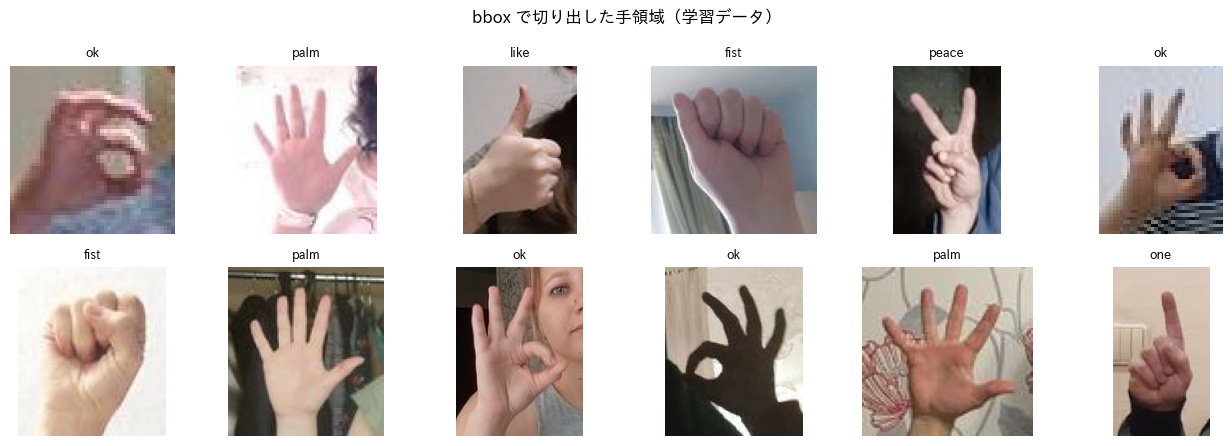

In [ ]:
def norm_bbox_to_px(bbox, W, H, margin=0.0):
    x, y, w, h = bbox
    cx, cy = x + w/2, y + h/2
    w2, h2 = w*(1+margin), h*(1+margin)
    x0 = int(round((cx - w2/2)*W)); y0 = int(round((cy - h2/2)*H))
    x1 = int(round((cx + w2/2)*W)); y1 = int(round((cy + h2/2)*H))
    x0 = max(0, min(x0, W-1)); y0 = max(0, min(y0, H-1))
    x1 = max(x0+1, min(x1, W)); y1 = max(y0+1, min(y1, H))
    return x0, y0, x1, y1

def load_rgb(path):
    return Image.open(path).convert("RGB")

def crop_hand(img_pil, bbox, margin=CROP_MARGIN):
    W, H = img_pil.size
    x0,y0,x1,y1 = norm_bbox_to_px(bbox, W, H, margin)
    return img_pil.crop((x0,y0,x1,y1))

def to_tensor_norm(img_pil, size=IMG_SIZE):
    img = img_pil.resize((size, size), Image.BILINEAR)
    arr = np.asarray(img, np.float32)/255.0           # HWC
    arr = (arr - np.array(MEAN, np.float32)) / np.array(STD, np.float32)
    t = torch.from_numpy(arr.transpose(2,0,1)).float() # CHW
    return t

class HandGestureDataset(Dataset):
    def __init__(self, recs): self.recs = recs
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        r = self.recs[i]
        img = load_rgb(r["path"])
        hand = crop_hand(img, r["bbox"])
        x = to_tensor_norm(hand)
        y = cls2idx[r["cls"]]
        return x, y

full_ds = HandGestureDataset(records)
n_val = max(1, int(len(full_ds)*VAL_RATIO)); n_tr = len(full_ds)-n_val
assert n_tr > 0, 'データが空です。上のデータ取得セルの出力（使用サンプル数）を確認してください。'
train_ds, val_ds = random_split(full_ds, [n_tr, n_val],
                                generator=torch.Generator().manual_seed(SEED))
train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, drop_last=True)
val_ld   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
print(f"train={len(train_ds)}  val={len(val_ds)}")

# 切り出しプレビュー
fig, axes = plt.subplots(2, 6, figsize=(13,4.5))
for ax, r in zip(axes.ravel(), records[:12]):
    img = load_rgb(r["path"]); hand = crop_hand(img, r["bbox"])
    ax.imshow(hand); ax.set_title(r["cls"], fontsize=9); ax.axis("off")
plt.suptitle("bbox で切り出した手領域（学習データ）"); plt.tight_layout(); plt.show()


## ステップ3：ジェスチャー分類 CNN を定義

`conv1`, `conv2`, `conv3` という名前の畳み込み層を持たせ、後で **forward hook** を掛けやすくする。
各ブロックは `Conv → BatchNorm → ReLU → MaxPool`。最後は Global Average Pooling → 全結合。

In [ ]:
class GestureCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2)
        self.fc    = nn.Linear(64, n_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 128 -> 64
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 64  -> 32
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 32  -> 16
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)       # GAP
        return self.fc(x)

model = GestureCNN(len(classes)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"総パラメータ数: {n_params:,}")


GestureCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)
総パラメータ数: 24,198


### 学習

**注意：精度を競うのが目的ではない。** feature map を観察するために、
「手の形にある程度反応するフィルタ」を学習で獲得させたいだけ。数エポックで十分。

epoch  1 | train loss 1.745 acc 0.259 | val loss 1.797 acc 0.194
epoch  2 | train loss 1.668 acc 0.314 | val loss 1.669 acc 0.298
epoch  3 | train loss 1.606 acc 0.365 | val loss 1.583 acc 0.321
epoch  4 | train loss 1.551 acc 0.398 | val loss 1.558 acc 0.337
epoch  5 | train loss 1.511 acc 0.425 | val loss 1.481 acc 0.381
epoch  6 | train loss 1.474 acc 0.435 | val loss 1.480 acc 0.400
epoch  7 | train loss 1.436 acc 0.456 | val loss 1.417 acc 0.448
epoch  8 | train loss 1.401 acc 0.462 | val loss 1.453 acc 0.410
epoch  9 | train loss 1.396 acc 0.451 | val loss 1.434 acc 0.429
epoch 10 | train loss 1.364 acc 0.483 | val loss 1.404 acc 0.429
epoch 11 | train loss 1.348 acc 0.476 | val loss 1.407 acc 0.429
epoch 12 | train loss 1.318 acc 0.498 | val loss 1.325 acc 0.476
epoch 13 | train loss 1.301 acc 0.524 | val loss 1.432 acc 0.425
epoch 14 | train loss 1.299 acc 0.516 | val loss 1.314 acc 0.495
epoch 15 | train loss 1.272 acc 0.532 | val loss 1.318 acc 0.470
epoch 16 | train loss 1.2

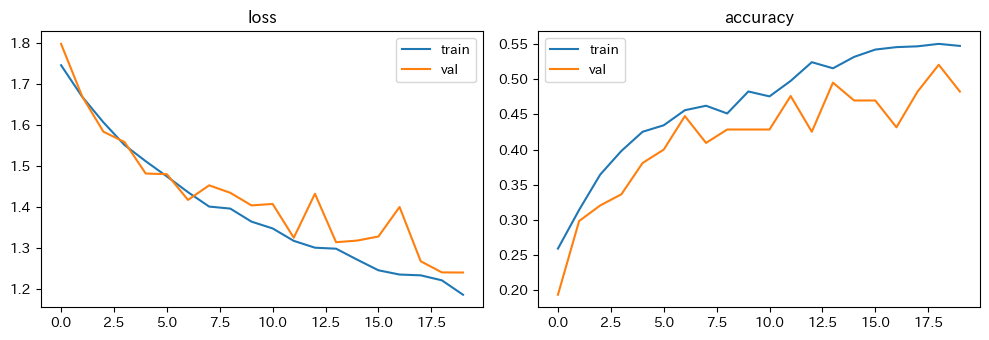

In [ ]:
opt = torch.optim.Adam(model.parameters(), lr=LR)
crit = nn.CrossEntropyLoss()

def run_epoch(loader, train):
    model.train(train)
    tot, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(train):
            out = model(x); loss = crit(out, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item(); tot += x.size(0)
    return loss_sum/tot, correct/tot

hist = []
for ep in range(1, EPOCHS+1):
    tl, ta = run_epoch(train_ld, True)
    vl, va = run_epoch(val_ld, False)
    hist.append((tl,ta,vl,va))
    print(f"epoch {ep:2d} | train loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}")

h = np.array(hist)
fig, ax = plt.subplots(1,2, figsize=(10,3.5))
ax[0].plot(h[:,0], label="train"); ax[0].plot(h[:,2], label="val"); ax[0].set_title("loss"); ax[0].legend()
ax[1].plot(h[:,1], label="train"); ax[1].plot(h[:,3], label="val"); ax[1].set_title("accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()
model.eval();


## ステップ4：3 種類の入力を作る

1つのサンプル画像から、次の3つを作る（すべて CNN 入力サイズ `IMG_SIZE` にそろえる）。

| 名称 | 内容 |
|---|---|
| **hand** | bounding box で切り出した手だけの画像 |
| **full** | 元の全体画像 |
| **masked** | 手の bounding box 部分をグレーで隠した全体画像 |

`full` / `masked` は **手の切り出しで学習したモデルにとっては想定外（out-of-distribution）の入力**。
だからこそ「ネットワークが手の領域・それ以外の領域にどう応答するか」を観察できる。
**予測ラベルは参考程度**（精度評価が目的ではない）。

選択サンプル: like | uid: aa8b5c22 | bbox面積比: 0.307


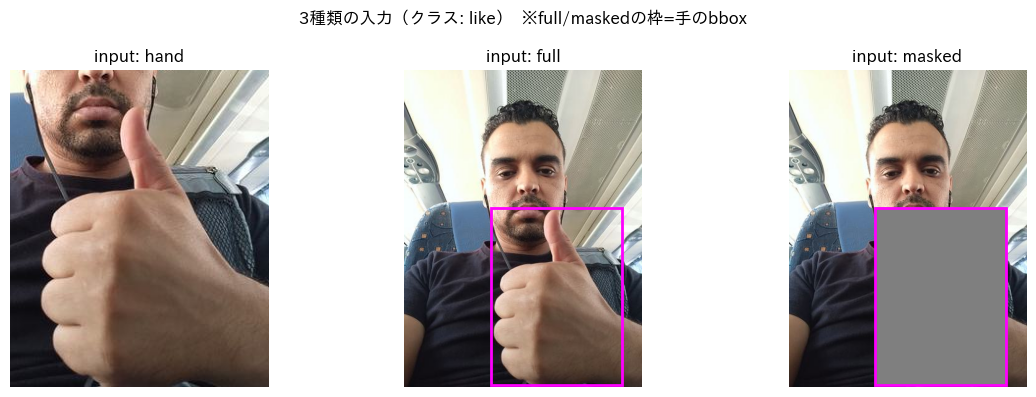

In [ ]:
def make_variants(record):
    img = load_rgb(record["path"])
    W, H = img.size
    bx = norm_bbox_to_px(record["bbox"], W, H, margin=0.0)   # 表示用の素の bbox(px)
    cx = norm_bbox_to_px(record["bbox"], W, H, margin=CROP_MARGIN)  # 切り出し範囲(px)

    # hand: 切り出し
    hand_pil = img.crop((cx[0],cx[1],cx[2],cx[3]))
    # full: 全体そのまま
    full_pil = img.copy()
    # masked: bbox をグレーで塗りつぶし
    masked_pil = img.copy()
    gray = tuple(int(m*255) for m in MEAN)
    from PIL import ImageDraw
    ImageDraw.Draw(masked_pil).rectangle([bx[0],bx[1],bx[2],bx[3]], fill=gray)

    variants = {
        "hand":   dict(disp=np.asarray(hand_pil),   tensor=to_tensor_norm(hand_pil),   bbox_px=None),
        "full":   dict(disp=np.asarray(full_pil),   tensor=to_tensor_norm(full_pil),   bbox_px=bx),
        "masked": dict(disp=np.asarray(masked_pil), tensor=to_tensor_norm(masked_pil), bbox_px=bx),
    }
    return variants

# 観察するサンプルを選ぶ（手が大きく写っている1枚を自動選択。SAMPLE_IDX を変えて差し替え可）
def bbox_area(r): return r["bbox"][2]*r["bbox"][3]
candidates = sorted(records, key=bbox_area, reverse=True)
SAMPLE_IDX = 0
sample = candidates[SAMPLE_IDX]
print("選択サンプル:", sample["cls"], "| uid:", sample["uid"][:8], "| bbox面積比:", round(bbox_area(sample),3))
variants = make_variants(sample)

fig, axes = plt.subplots(1,3, figsize=(12,4))
for ax,(name,v) in zip(axes, variants.items()):
    ax.imshow(v["disp"]); ax.set_title(f"input: {name}"); ax.axis("off")
    if v["bbox_px"] is not None:
        x0,y0,x1,y1 = v["bbox_px"]
        ax.add_patch(patches.Rectangle((x0,y0),x1-x0,y1-y0, fill=False, edgecolor="magenta", lw=2))
plt.suptitle(f"3種類の入力（クラス: {sample['cls']}）  ※full/maskedの枠=手のbbox"); plt.tight_layout(); plt.show()


## ステップ5：forward hook で Conv1 / Conv2 / Conv3 の中間出力を取り出す

`conv1`, `conv2`, `conv3` の**出力（= その層の生の畳み込み応答, ReLU 前）**を捕まえる。
これが「CNN の直接応答 = feature map」である。

In [ ]:
# 取り出す層（モジュール名でアクセス）
HOOK_LAYERS = {"conv1": model.conv1, "conv2": model.conv2, "conv3": model.conv3}

_captured = {}
def _mk_hook(name):
    def hook(module, inp, out):
        _captured[name] = out.detach().cpu().numpy()[0]  # (C,H,W) バッチ先頭
    return hook
_handles = [m.register_forward_hook(_mk_hook(n)) for n,m in HOOK_LAYERS.items()]

@torch.no_grad()
def run_and_capture(tensor_chw):
    _captured.clear()
    x = tensor_chw.unsqueeze(0).to(DEVICE)
    logits = model(x)
    probs = F.softmax(logits, 1)[0].cpu().numpy()
    acts = {k: v.copy() for k,v in _captured.items()}   # {layer:(C,H,W)}
    return acts, probs

# 動作確認
acts, probs = run_and_capture(variants["hand"]["tensor"])
for k,v in acts.items(): print(f"{k}: feature map shape (C,H,W) = {v.shape}")
print("予測:", idx2cls[int(probs.argmax())], "確率:", round(float(probs.max()),3))


conv1: feature map shape (C,H,W) = (16, 128, 128)
conv2: feature map shape (C,H,W) = (32, 64, 64)
conv3: feature map shape (C,H,W) = (64, 32, 32)
予測: ok 確率: 0.443


## ステップ6・7：可視化ヘルパー（タイル化 と チャンネル方向 PCA）

- **タイル化**：各チャンネルを個別に min–max 正規化（0〜1）し、格子状に並べる。
- **チャンネル方向 PCA**：feature map `(C,H,W)` の **各画素を C 次元ベクトル**とみなし、
  `H×W` 個のサンプルで PCA。第1〜4主成分の係数を `H×W` に戻すと「主成分画像」になる。
  チャンネル横断で共通する応答パターンを 4 枚に圧縮して見るための手法。

In [ ]:
def normalize_per_channel(a):              # (C,H,W) -> [0,1] 各ch個別
    C = a.shape[0]; flat = a.reshape(C,-1)
    mn = flat.min(1, keepdims=True); mx = flat.max(1, keepdims=True)
    return ((flat-mn)/(mx-mn+1e-8)).reshape(a.shape)

def tile(a, cols=None, pad=1, bg=0.15):     # (C,H,W in [0,1]) -> 2D モザイク
    C,H,W = a.shape
    cols = cols or int(np.ceil(np.sqrt(C))); rows = int(np.ceil(C/cols))
    canvas = np.full((rows*(H+pad)+pad, cols*(W+pad)+pad), bg, np.float32)
    for i in range(C):
        r,c = divmod(i, cols); y0=pad+r*(H+pad); x0=pad+c*(W+pad)
        canvas[y0:y0+H, x0:x0+W] = a[i]
    return canvas

def channel_pca_images(a, n_comp=4):        # (C,H,W) -> (k,H,W)[0,1], 寄与率
    C,H,W = a.shape
    X = a.reshape(C, H*W).T                  # (画素, ch)
    k = min(n_comp, C, X.shape[0])
    pca = PCA(n_components=k); proj = pca.fit_transform(X)   # (画素,k)
    imgs = proj.T.reshape(k, H, W)
    return normalize_per_channel(imgs), pca.explained_variance_ratio_


## ステップ8・9：統合表示（入力・予測・生 feature map・PCA を並べる）

1つの入力につき：左に **入力画像（full/masked は手の bbox を重畳）＋予測ラベル/確率**、
右に各 Conv 層の **生 feature map タイル** と **PCA 第1〜4主成分** を並べる。
画像は `/content/outputs/` に PNG 保存される。

saved: /content/outputs/like_aa8b5c22_hand.png


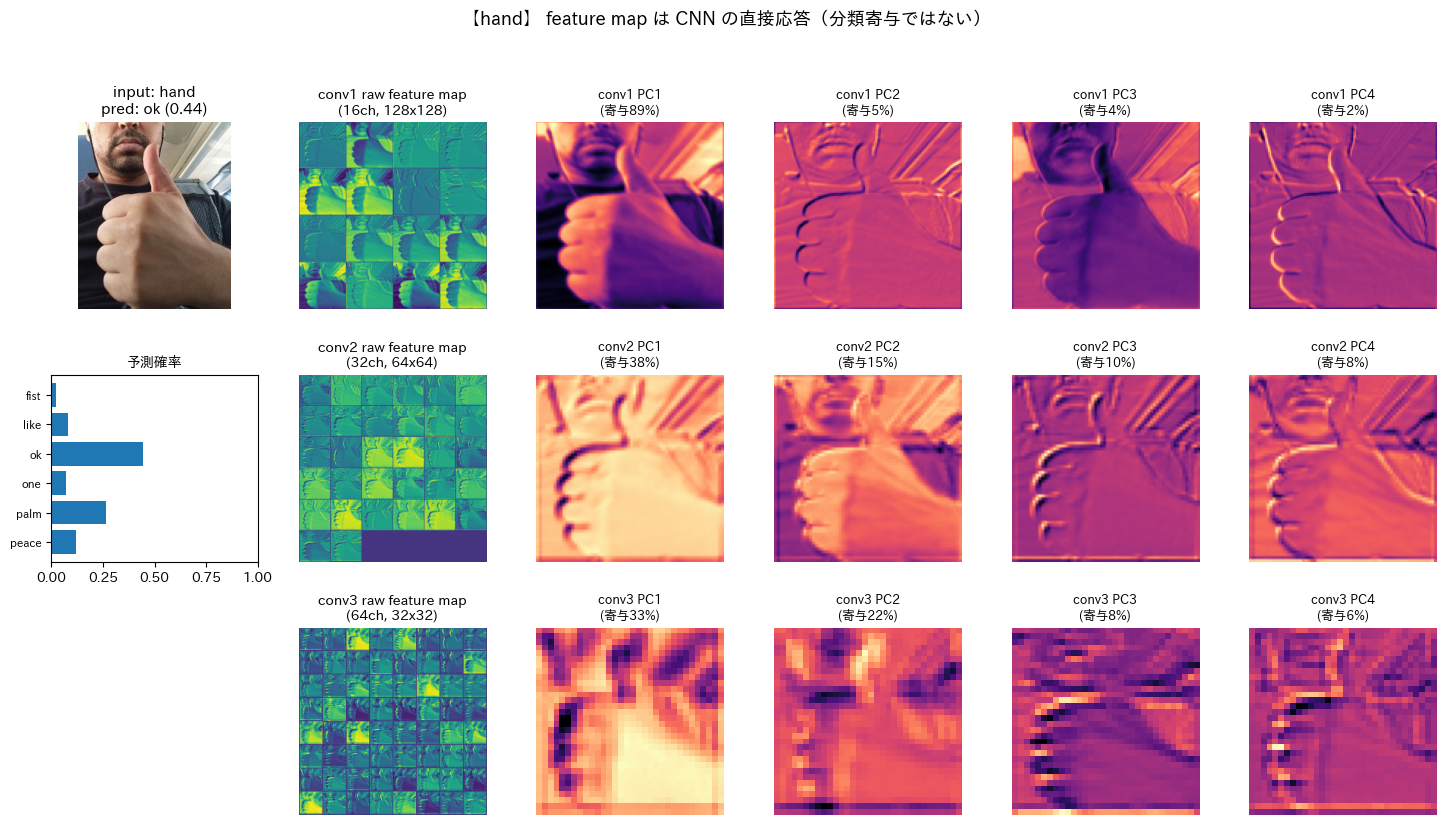

saved: /content/outputs/like_aa8b5c22_full.png


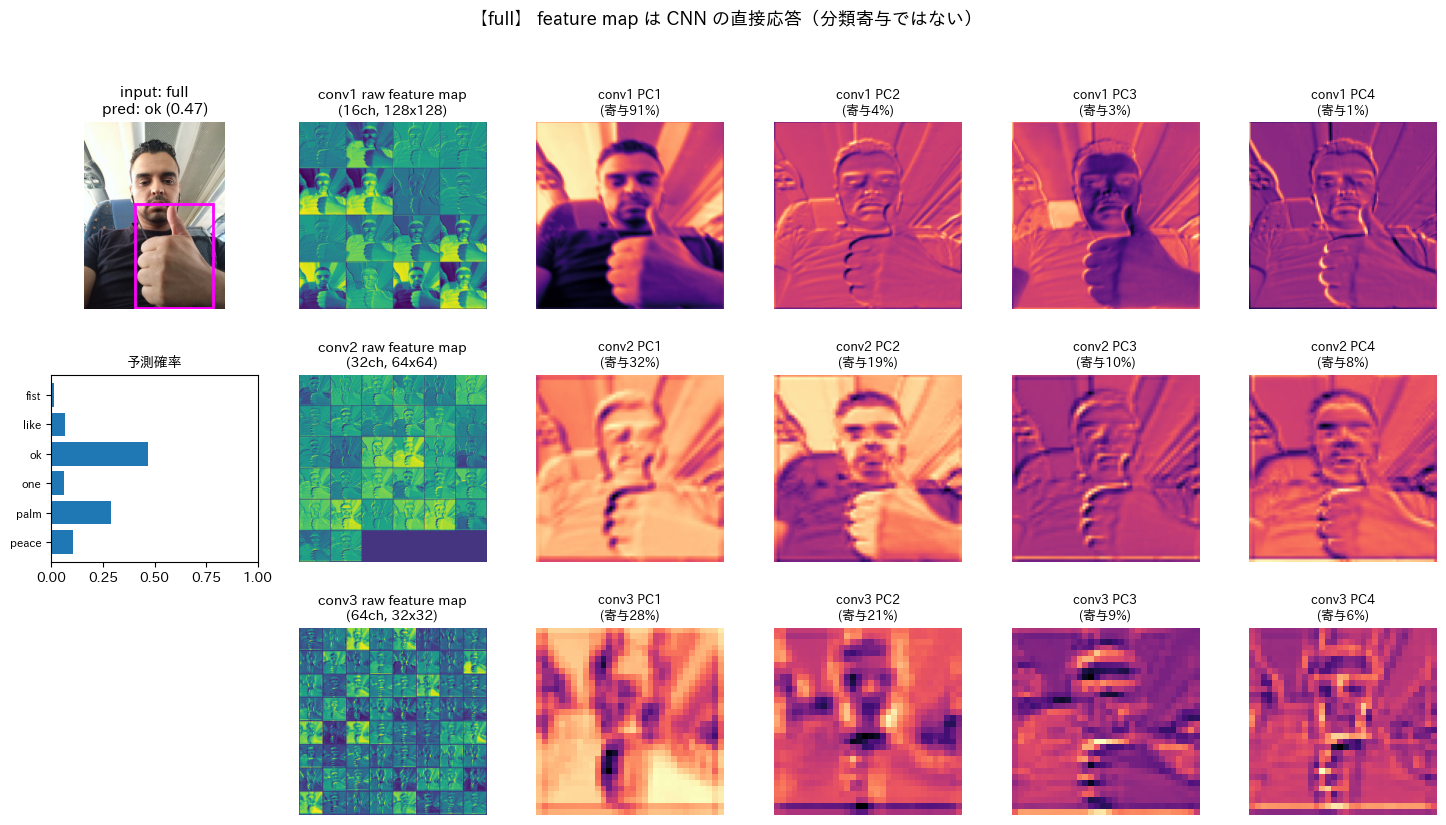

saved: /content/outputs/like_aa8b5c22_masked.png


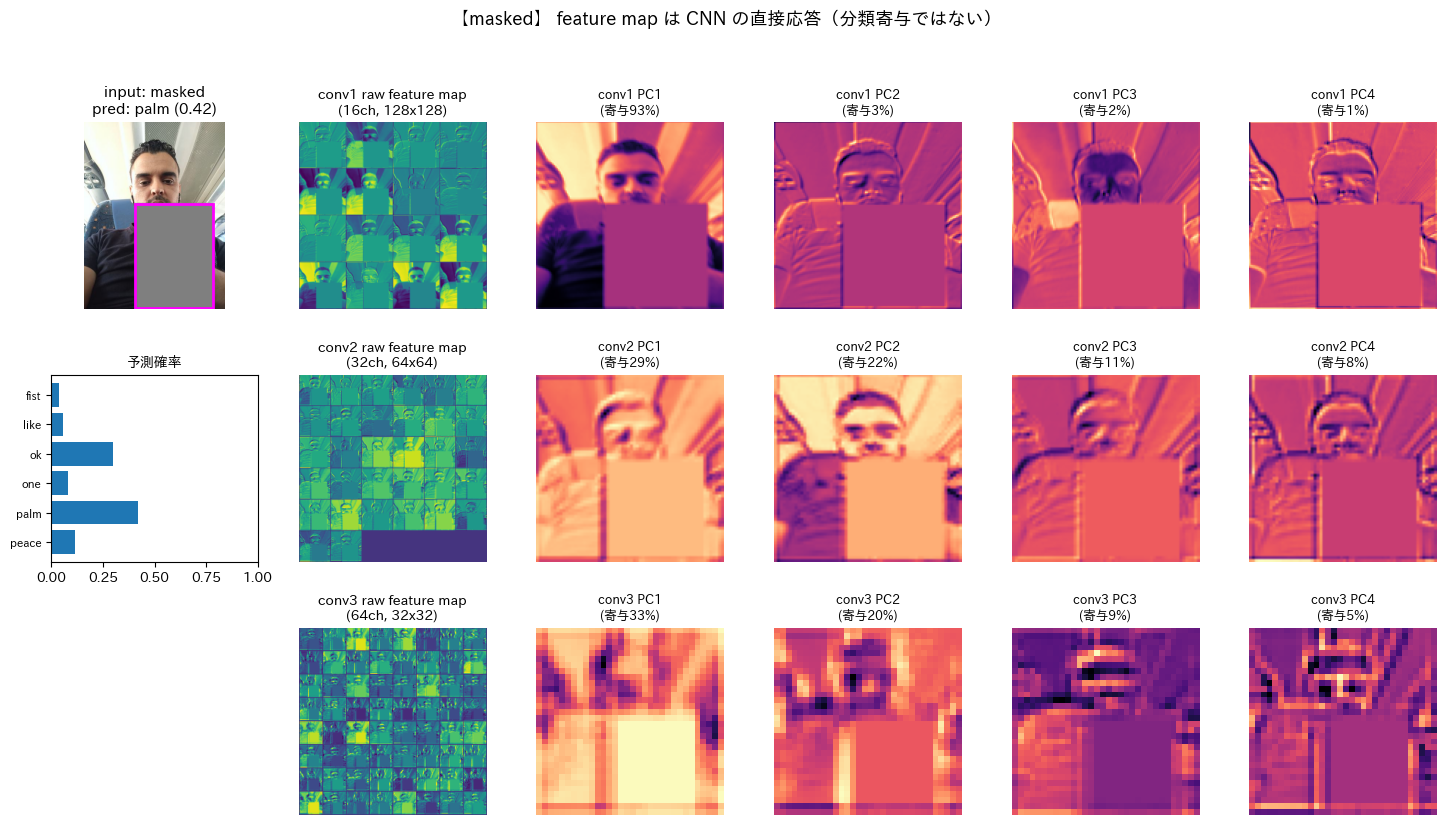

In [ ]:
LAYER_ORDER = ["conv1", "conv2", "conv3"]
MAX_TILE_CH = 64   # タイルに並べる最大チャンネル数

def visualize_input(name, variant, sample, save=True):
    acts, probs = run_and_capture(variant["tensor"])
    pred = int(probs.argmax())

    nrows = len(LAYER_ORDER)
    ncols = 1 + 1 + 4    # [入力(1行目だけ)] / 生タイル / PC1..PC4
    fig = plt.figure(figsize=(3.0*ncols, 3.0*nrows))
    gs = fig.add_gridspec(nrows, ncols, hspace=0.35, wspace=0.15)

    # 左端の縦長: 入力画像（1枚を上部に）＋ 予測確率バー（下部）
    ax_img = fig.add_subplot(gs[0, 0]); ax_img.imshow(variant["disp"]); ax_img.axis("off")
    title = f"input: {name}\npred: {idx2cls[pred]} ({probs[pred]:.2f})"
    ax_img.set_title(title, fontsize=11)
    if variant["bbox_px"] is not None:
        x0,y0,x1,y1 = variant["bbox_px"]
        ax_img.add_patch(patches.Rectangle((x0,y0),x1-x0,y1-y0, fill=False, edgecolor="magenta", lw=2))
    ax_bar = fig.add_subplot(gs[1, 0])
    ax_bar.barh(range(len(classes)), probs); ax_bar.set_yticks(range(len(classes)))
    ax_bar.set_yticklabels(classes, fontsize=8); ax_bar.invert_yaxis()
    ax_bar.set_xlim(0,1); ax_bar.set_title("予測確率", fontsize=10)
    fig.add_subplot(gs[2,0]).axis("off")

    # 各 Conv 層: 生タイル + PCA
    for r, layer in enumerate(LAYER_ORDER):
        fmap = acts[layer]                      # (C,H,W)
        tiled = tile(normalize_per_channel(fmap[:MAX_TILE_CH]))
        axt = fig.add_subplot(gs[r, 1]); axt.imshow(tiled, cmap="viridis")
        axt.set_title(f"{layer} raw feature map\n({fmap.shape[0]}ch, {fmap.shape[1]}x{fmap.shape[2]})", fontsize=10)
        axt.axis("off")
        pcs, evr = channel_pca_images(fmap, 4)
        for j in range(4):
            axp = fig.add_subplot(gs[r, 2+j]); axp.axis("off")
            if j < pcs.shape[0]:
                axp.imshow(pcs[j], cmap="magma")
                axp.set_title(f"{layer} PC{j+1}\n(寄与{evr[j]*100:.0f}%)", fontsize=9)

    fig.suptitle(f"【{name}】 feature map は CNN の直接応答（分類寄与ではない）", fontsize=13, y=1.005)
    if save:
        p = OUT_DIR / f"{sample['cls']}_{sample['uid'][:8]}_{name}.png"
        fig.savefig(p, dpi=110, bbox_inches="tight"); print("saved:", p)
    plt.show()
    return acts, probs

for name, v in variants.items():
    visualize_input(name, v, sample)


### 各層のタイル画像・PCA 画像を個別ファイルにも保存

レポートや講義スライドに貼りやすいよう、層ごとに **生 feature map タイル** と
**PCA 第1〜4主成分** を別々の PNG としても書き出す。

In [ ]:
def save_layer_images(name, variant, sample):
    acts, _ = run_and_capture(variant["tensor"])
    base = OUT_DIR / f"{sample['cls']}_{sample['uid'][:8]}_{name}"
    for layer in LAYER_ORDER:
        fmap = acts[layer]
        # 生タイル
        plt.imsave(f"{base}_{layer}_tile.png",
                   tile(normalize_per_channel(fmap[:MAX_TILE_CH])), cmap="viridis")
        # PCA 4枚を横連結
        pcs, _ = channel_pca_images(fmap, 4)
        strip = np.concatenate([pcs[j] for j in range(pcs.shape[0])], axis=1)
        plt.imsave(f"{base}_{layer}_pca.png", strip, cmap="magma")
    print("saved tile/pca for:", name)

for name, v in variants.items():
    save_layer_images(name, v, sample)

print("\n--- /content/outputs の中身 ---")
for f in sorted(OUT_DIR.glob("*.png")): print(" ", f.name)


saved tile/pca for: hand
saved tile/pca for: full
saved tile/pca for: masked

--- /content/outputs の中身 ---
  like_aa8b5c22_full.png
  like_aa8b5c22_full_conv1_pca.png
  like_aa8b5c22_full_conv1_tile.png
  like_aa8b5c22_full_conv2_pca.png
  like_aa8b5c22_full_conv2_tile.png
  like_aa8b5c22_full_conv3_pca.png
  like_aa8b5c22_full_conv3_tile.png
  like_aa8b5c22_hand.png
  like_aa8b5c22_hand_conv1_pca.png
  like_aa8b5c22_hand_conv1_tile.png
  like_aa8b5c22_hand_conv2_pca.png
  like_aa8b5c22_hand_conv2_tile.png
  like_aa8b5c22_hand_conv3_pca.png
  like_aa8b5c22_hand_conv3_tile.png
  like_aa8b5c22_masked.png
  like_aa8b5c22_masked_conv1_pca.png
  like_aa8b5c22_masked_conv1_tile.png
  like_aa8b5c22_masked_conv2_pca.png
  like_aa8b5c22_masked_conv2_tile.png
  like_aa8b5c22_masked_conv3_pca.png
  like_aa8b5c22_masked_conv3_tile.png


## ステップ10：まとめと注意（必読）

### 観察のポイント
- **conv1**：エッジ・色・明暗など低次の局所パターンに反応。解像度が高く、手の輪郭が見えやすい。
- **conv2 → conv3**：解像度が下がり、より広い範囲をまとめた中〜高次の応答になる。
  チャンネルごとに「反応する形」が分かれていく様子が見える。
- **PCA 第1〜4主成分**：多数チャンネルに共通する応答構造を 4 枚に圧縮したもの。
  「層全体としてどこに強く応答しているか」の概観として読む。

### 3 入力の比較で分かること
- **hand**：学習時と同じ分布。手の構造に沿った応答が出やすい。
- **full**：手以外（顔・背景）にも応答が出る。手の領域だけが特別なわけではない。
- **masked**：手を隠すと、その場所の応答がどう変わるかを観察できる。

### ⚠️ 結論として強調すること
- ここに出した画像は **すべて「CNN の中間層が入力に返した応答（feature map）」** である。
- **明るい＝強く応答した場所** であって、**「分類の根拠になった場所」ではない**。
  応答（activation）と寄与（attribution / 説明）は別概念。
- 分類への寄与を見たい場合は Grad-CAM などの**別の手法**が必要だが、
  **本教材はそれを扱わない**。ここで観察したのは、あくまで CNN の**直接の応答**である。

---
#### 使い方メモ
- `SAMPLE_IDX` を変えると観察する画像が変わる（手が大きい順に並んでいる）。
- `SELECTED_CLASSES` / `MAX_PER_CLASS` / `EPOCHS` で軽さと学習度合いを調整。
- `HOOK_LAYERS` に層を足せば、より深い層の応答も観察できる。
- 出力 PNG は `/content/outputs/` に保存される（左サイドバーのファイルからダウンロード可）。

## おまけ：Grad-CAM（※ CNN が内部で作る画像ではない）

前半で見た **feature map は、順伝播でネットワークから実際に出てくる「直接の応答」** だった。
一方 **Grad-CAM は、学習済みネットワークに対して後から計算する「分類寄与（attribution）」の推定**であり、
**ネットワークの内部にこのようなヒートマップが流れているわけではない。**

#### Grad-CAM の作り方（＝なぜ「内部の産物」ではないか）
1. 入力を**順伝播**し、注目するクラスのスコアを取り出す。
2. そのスコアを、ある畳み込み層の**特徴マップで微分（逆伝播）**して勾配を得る。
3. 勾配をチャンネルごとに空間平均し、「各チャンネルの重要度の重み」とする。
4. 特徴マップを重み付き和して **ReLU** → 入力サイズに拡大する。

このうち **手順2〜4 は、推論時の順伝播には存在しない「解析のための追加計算」**である。
つまり Grad-CAM は *勾配を使って外側から作る説明* であって、CNN が応答として吐き出すものではない。
ここでは対象層を **最後の畳み込み層（`conv3`）** とする（Grad-CAM の定番）。

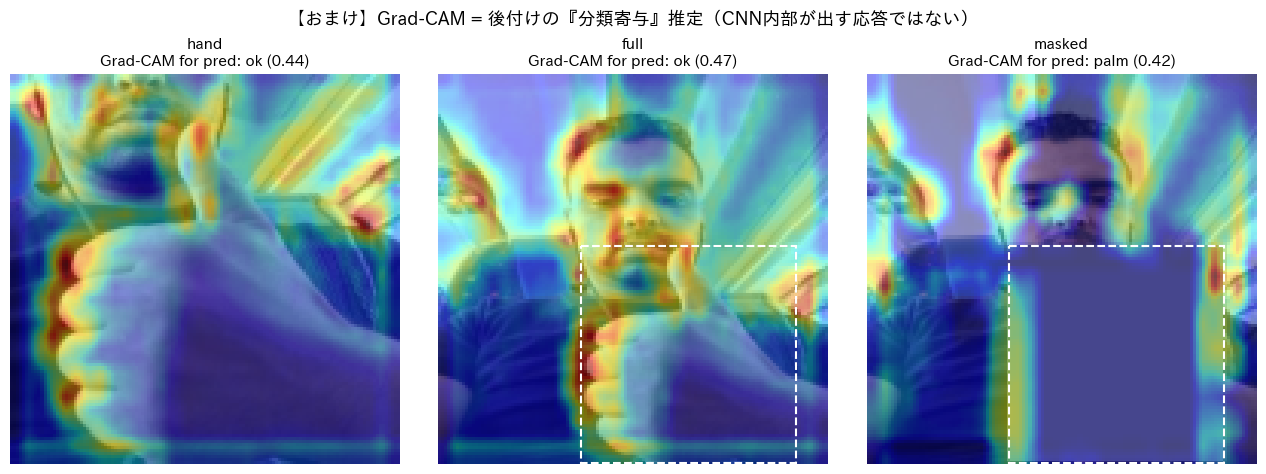

Grad-CAM はクラススコアを conv3 の特徴マップで微分して作った『説明』であり、
順伝播でネットワークから出てくる量ではない点に注意。


In [ ]:
# ===== Grad-CAM（後付けの「分類寄与」推定。順伝播の応答ではない）=====
GRADCAM_LAYER = model.conv3        # 対象層（最後の畳み込み層が定番）

def grad_cam(input_tensor, target_layer=GRADCAM_LAYER, class_idx=None):
    """順伝播で特徴マップを保存し、クラススコアを逆伝播して勾配を取得 → 加重和。
    ※これは推論には無い『追加の解析計算』であり、CNN内部の応答ではない。"""
    model.eval()
    store = {}
    def fhook(m, i, o):
        store["act"] = o                                   # 順伝播の特徴マップ
        o.register_hook(lambda g: store.__setitem__("grad", g))  # その勾配を後で受け取る
    h = target_layer.register_forward_hook(fhook)
    try:
        x = input_tensor.unsqueeze(0).to(DEVICE)
        logits = model(x)                                   # 順伝播（勾配あり）
        probs = F.softmax(logits, 1)[0]
        if class_idx is None:
            class_idx = int(logits.argmax(1))
        model.zero_grad(set_to_none=True)
        logits[0, class_idx].backward()                     # ← 逆伝播（ここがGrad-CAM固有）
        A = store["act"][0]                                 # (C,h,w)
        G = store["grad"][0]                                # (C,h,w)
        weights = G.mean(dim=(1, 2))                        # チャンネル重要度 = 勾配の空間平均
        cam = torch.relu((weights[:, None, None] * A).sum(0))
        cam = (cam / (cam.max() + 1e-8)).detach().cpu().numpy()
    finally:
        h.remove()                                          # フックは必ず外す
    return cam, class_idx, probs.detach().cpu().numpy()

def denorm_input(t):                                        # ネットワークが実際に見た128px入力に戻す
    arr = t.cpu().numpy().transpose(1, 2, 0) * np.array(STD) + np.array(MEAN)
    return np.clip(arr, 0, 1)

def upsample_cam(cam, size=IMG_SIZE):                       # 32x32 → 128x128 に拡大
    im = Image.fromarray((cam * 255).astype(np.uint8)).resize((size, size), Image.BILINEAR)
    return np.asarray(im, np.float32) / 255.0

# 3種類の入力それぞれで Grad-CAM（既定は予測クラスに対して計算）
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (name, v) in zip(axes, variants.items()):
    base = denorm_input(v["tensor"])
    cam, ci, probs = grad_cam(v["tensor"])     # class_idx=数値 を渡せば任意クラスでも見られる
    ax.imshow(base)
    ax.imshow(upsample_cam(cam), cmap="jet", alpha=0.45)   # ヒートマップを重畳
    ax.set_title(f"{name}\nGrad-CAM for pred: {idx2cls[ci]} ({probs[ci]:.2f})", fontsize=11)
    ax.axis("off")
    if v["bbox_px"] is not None:                # full/masked は手のbboxを128px枠に換算して点線表示
        x, y, w, h = sample["bbox"]
        ax.add_patch(patches.Rectangle((x*IMG_SIZE, y*IMG_SIZE), w*IMG_SIZE, h*IMG_SIZE,
                                       fill=False, edgecolor="white", lw=1.5, linestyle="--"))

fig.suptitle("【おまけ】Grad-CAM = 後付けの『分類寄与』推定（CNN内部が出す応答ではない）",
             y=1.02, fontsize=13)
plt.tight_layout()
fig.savefig(OUT_DIR / f"{sample['cls']}_{sample['uid'][:8]}_gradcam.png", dpi=110, bbox_inches="tight")
plt.show()
print("Grad-CAM はクラススコアを conv3 の特徴マップで微分して作った『説明』であり、")
print("順伝播でネットワークから出てくる量ではない点に注意。")


### feature map と Grad-CAM の違い（まとめ）

| | feature map（前半・本題） | Grad-CAM（このおまけ） |
|---|---|---|
| 正体 | 畳み込み層の **直接の応答（活性）** | クラススコアの **分類寄与の推定** |
| 計算 | **順伝播**で出てくる量 | **逆伝播の勾配**を使い後付けで計算 |
| ネット内部に存在するか | する（実際に流れる） | **しない**（外付けの解析結果） |
| 明るさの意味 | 「そのフィルタが強く反応した場所」 | 「そのクラスと判断する根拠（と推定される）場所」 |
| 本教材での位置づけ | 主題 | あくまで参考 |

**要点：明るい場所の意味がまったく違う。** feature map の明るさは *応答の強さ*、
Grad-CAM の明るさは *分類への寄与（の推定）*。
ヒートマップが CNN の中で生成・保持されているわけではなく、勾配から外側で組み立てた説明である——
この区別を、本題（feature map の観察）と地続きに語らないことが重要。